<a href="https://colab.research.google.com/github/JuanBattaglio/Proyecto_Busqueda/blob/main/Notebook_Modelo2_Phi3_mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Final — Análisis de Sentimientos con LLMs
## Modelo 2: `microsoft/Phi-3-mini-4k-instruct`

---

**Asignatura:** Búsqueda y Análisis de Información  
**Grupo:** [Nombre del grupo]  
**Autores:** [Autor 1], [Autor 2], [Autor 3]  
**Fecha:** Mayo 2026  

---

### Descripción del modelo

**Phi-3-mini-4k-instruct** es un modelo de lenguaje de Microsoft lanzado en **abril de 2024**, con **3.8 mil millones de parámetros** y una ventana de contexto de **4096 tokens**. Pertenece a la familia Phi-3, diseñada para maximizar el rendimiento en tareas de razonamiento con un tamaño reducido. La variante `instruct` ha sido ajustada mediante RLHF para seguir instrucciones en formato conversacional.

| Característica | Valor |
|---|---|
| Parámetros | 3.8B |
| Fecha de lanzamiento | Abril 2024 |
| Ventana de contexto | 4096 tokens |
| Tipo | Decoder-only, instruction-tuned |
| Arquitectura | Transformer con grouped-query attention |
| Licencia | MIT |

### Tarea abordada

Clasificación de mensajes en español según tres dimensiones:
- **Sentimiento**: tristeza / alegría / neutralidad
- **Subjetividad**: objetivo / subjetivo
- **Polaridad**: positivo / negativo / neutro

### Estrategias de prompt engineering evaluadas

1. **Prompt base**: instrucción mínima, sin estructura definida
2. **Prompt plantilla**: estructura formal con Tarea, Contexto, Restricciones, Formato y Criterio de calidad
3. **Prompt de razonamiento**: análisis paso a paso con contraste de alternativas y conclusión justificada

### Índice

0. Instalación de dependencias
1. Configuración del entorno
2. Carga del modelo
3. Dataset y etiquetas de referencia
4. Definición de prompts
5. Parámetros y función de inferencia
6. Ejecución del experimento
7. Métricas objetivas
8. Análisis de variabilidad
9. Visualizaciones
10. Conclusiones

---
## 0. Instalacion de dependencias

Ejecuta esta celda si alguna de las librerías necesarias no está instalada en tu entorno.
En **Google Colab** se recomienda ejecutarla siempre. En **entorno local** solo es necesaria la primera vez.

> **Nota:** Después de la instalación puede ser necesario **reiniciar el kernel** antes de continuar.

In [1]:
# Instalar versiones específicas compatibles entre sí para Phi-3-mini
# transformers 4.44.x + huggingface_hub < 0.30 evitan el StrictDataclassDefinitionError

!pip install \
    "transformers==4.44.2" \
    "huggingface_hub==0.24.6" \
    "accelerate>=0.26.0" \
    sentencepiece protobuf -q

# Verificar versiones instaladas
import importlib
for pkg in ['torch', 'transformers', 'huggingface_hub', 'accelerate', 'sentencepiece']:
    try:
        mod = importlib.import_module(pkg)
        print(f'  {pkg}: {getattr(mod, "__version__", "instalado")}')
    except ImportError:
        print(f'  {pkg}: NO instalado')

print("\nREINICIA el runtime de Colab antes de continuar (Entorno de ejecución → Reiniciar sesión)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 48.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.24.6 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.24.6 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.24.6 which is incompatible.
  torch: 2.10.0+cu128
  transformers: 4.44.2
  huggingface_hub: 0.24.6
  accelerate: 1.13.0
  sentencepiece: 0.2.1

REINICIA el runtime de Colab antes de continuar (Entorno de ej

---
## 1. Configuración del entorno <a id='sec1'></a>

Importamos las librerías necesarias y detectamos el hardware disponible.

In [2]:
import torch
import time
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Detectar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    vram_libre = torch.cuda.mem_get_info()[0] / 1e9
    print(f"VRAM total: {vram_total:.1f} GB")
    print(f"VRAM libre: {vram_libre:.1f} GB")
else:
    print("ADVERTENCIA: No se detectó GPU. El modelo tardará considerablemente más en CPU.")

print(f"\nPyTorch version: {torch.__version__}")

Dispositivo: cuda
GPU: Tesla T4
VRAM total: 15.6 GB
VRAM libre: 15.5 GB

PyTorch version: 2.10.0+cu128


---
## 2. Carga del modelo <a id='sec2'></a>

Cargamos `microsoft/Phi-3-mini-4k-instruct` desde HuggingFace. El modelo ocupa aproximadamente **7.6 GB en float16** en VRAM. Si tu GPU tiene menos de 8 GB, considera usar `torch.float32` en CPU o añadir cuantización con `bitsandbytes`.

> **Nota:** La primera ejecución descargará los pesos del modelo (~7 GB). Las ejecuciones posteriores los cargarán desde caché local.

In [3]:
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

print(f"Cargando tokenizador de '{MODEL_ID}'...")
# trust_remote_code=False: usar implementación nativa de transformers >= 4.40
# Evita el modeling_phi3.py cacheado que tiene incompatibilidades con el config actual
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print("Cargando modelo (float16, device_map=auto)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

print("Creando pipeline de generación de texto...")
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

print("\nModelo cargado correctamente.")
if hasattr(model, 'hf_device_map'):
    print(f"Dispositivos usados: {set(model.hf_device_map.values())}")

Cargando tokenizador de 'microsoft/Phi-3-mini-4k-instruct'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Creando pipeline de generación de texto...

Modelo cargado correctamente.
Dispositivos usados: {0}


### 2.1 Test de conexión

Verificamos que el modelo responde correctamente con una pregunta neutral antes de lanzar el experimento.

In [10]:
test_messages = [{"role": "user", "content": "¿Cuál es la capital de Francia? Responde en una frase."}]

test_output = pipe(test_messages, max_new_tokens=50, do_sample=False)
test_respuesta = test_output[0]["generated_text"][-1]["content"]

print("=== TEST DE CONEXIÓN ===")
print(f"Pregunta: ¿Cuál es la capital de Francia?")
print(f"Respuesta: {test_respuesta}")
print("========================")

=== TEST DE CONEXIÓN ===
Pregunta: ¿Cuál es la capital de Francia?
Respuesta:  La capital de Francia es París.


---
## 3. Dataset y etiquetas de referencia <a id='sec3'></a>

Definimos 5 mensajes en español que cubren los diferentes valores posibles de las tres dimensiones de clasificación. Las **etiquetas gold** (de referencia) nos permiten medir la exactitud objetiva del modelo.

| # | Sentimiento | Subjetividad | Polaridad | Descripción |
|---|---|---|---| --- |
| 1 | tristeza | subjetivo | negativo | Despido inesperado |
| 2 | alegría | subjetivo | positivo | Éxito académico |
| 3 | neutralidad | objetivo | neutro | Aviso de reunión |
| 4 | tristeza | subjetivo | negativo | Pérdida de un familiar |
| 5 | alegría | subjetivo | positivo | Victoria deportiva |

In [9]:
mensajes = [
    {
        "id": 1,
        "texto": "Hoy me han despedido del trabajo sin previo aviso. No sé cómo voy a pagar el alquiler este mes. Me siento completamente perdido y sin saber qué hacer.",
        "sentimiento": "tristeza",
        "subjetividad": "subjetivo",
        "polaridad": "negativo",
    },
    {
        "id": 2,
        "texto": "¡Acabo de aprobar todas las asignaturas con matrícula de honor! Es el mejor resultado de toda mi carrera. Estoy increíblemente feliz y orgulloso de mí mismo.",
        "sentimiento": "alegría",
        "subjetividad": "subjetivo",
        "polaridad": "positivo",
    },
    {
        "id": 3,
        "texto": "La reunión del departamento está programada para el martes a las 10:00 en la sala de conferencias B. La asistencia es obligatoria para todos los empleados.",
        "sentimiento": "neutralidad",
        "subjetividad": "objetivo",
        "polaridad": "neutro",
    },
    {
        "id": 4,
        "texto": "Mi abuela falleció esta mañana. Era la persona más importante de mi vida y no puedo imaginar el mundo sin ella. El dolor que siento ahora es insoportable.",
        "sentimiento": "tristeza",
        "subjetividad": "subjetivo",
        "polaridad": "negativo",
    },
    {
        "id": 5,
        "texto": "¡Hemos ganado el campeonato regional de fútbol! El equipo lo ha dado absolutamente todo esta temporada y merecemos esta victoria más que nadie. ¡Somos los mejores!",
        "sentimiento": "alegría",
        "subjetividad": "subjetivo",
        "polaridad": "positivo",
    },
]

df_mensajes = pd.DataFrame(mensajes)
print("Dataset de mensajes:")
display(df_mensajes[['id', 'sentimiento', 'subjetividad', 'polaridad', 'texto']])

Dataset de mensajes:


,id,sentimiento,subjetividad,polaridad,texto
0,1,tristeza,subjetivo,negativo,Hoy me han despedido del trabajo sin previo av...
1,2,alegría,subjetivo,positivo,¡Acabo de aprobar todas las asignaturas con ma...
2,3,neutralidad,objetivo,neutro,La reunión del departamento está programada pa...
3,4,tristeza,subjetivo,negativo,Mi abuela falleció esta mañana. Era la persona...
4,5,alegría,subjetivo,positivo,¡Hemos ganado el campeonato regional de fútbol...


---
## 4. Definición de prompts <a id='sec4'></a>

Los tres prompts abordan el **mismo problema** con diferente nivel de estructura y detalle. Esto nos permite aislar el efecto de la estrategia de prompting en la calidad de la respuesta.

### Prompt 1 — Base
Instrucción directa y mínima, sin estructura formal ni ejemplos. Sirve como línea base para la comparación.

### Prompt 2 — Plantilla estructurada
Sigue el esquema enseñado en clase: **Tarea + Contexto + Restricciones + Formato de salida + Criterio de calidad**. Proporciona información explícita sobre cómo responder.

### Prompt 3 — Razonamiento paso a paso
Solicita al modelo que analice el texto en etapas, contraste alternativas y justifique su conclusión. Favorece la transparencia del proceso de decisión.

In [8]:
def prompt_base(texto: str) -> str:
    return f"""Analiza el siguiente mensaje y clasifícalo según:
1. Sentimiento: tristeza, alegría o neutralidad
2. Subjetividad: objetivo o subjetivo
3. Polaridad: positivo, negativo o neutro

Mensaje: "{texto}"""


def prompt_plantilla(texto: str) -> str:
    return f"""Tarea: Clasifica el siguiente mensaje según su sentimiento, subjetividad y polaridad.

Contexto: Eres un sistema de análisis de sentimientos integrado en una plataforma de comunicación empresarial. Los mensajes son textos en español escritos por usuarios reales en distintos contextos.

Restricciones:
- Usa únicamente la información contenida en el mensaje proporcionado.
- No hagas suposiciones sobre el autor ni el contexto externo.
- Responde de forma concisa y estructurada.

Formato de salida:
- Sentimiento: [tristeza / alegría / neutralidad]
- Subjetividad: [objetivo / subjetivo]
- Polaridad: [positivo / negativo / neutro]
- Justificación: [máximo 2 frases explicando la clasificación]

Criterio de calidad: La clasificación debe reflejar el tono predominante del mensaje, no elementos aislados.

Mensaje: "{texto}"""


def prompt_razonamiento(texto: str) -> str:
    return f"""Analiza el siguiente mensaje paso a paso:

Paso 1: Identifica las palabras o expresiones con carga emocional positiva presentes en el mensaje.
Paso 2: Identifica las palabras o expresiones con carga emocional negativa presentes en el mensaje.
Paso 3: Evalúa si el mensaje expresa opiniones o sentimientos personales (subjetivo) o si describe hechos verificables (objetivo).
Paso 4: Considera las tres opciones de sentimiento (tristeza, alegría, neutralidad) y argumenta cuál se ajusta mejor al tono global.
Paso 5: Determina la polaridad (positivo, negativo, neutro) comparando el peso de los elementos identificados.
Paso 6: Proporciona una conclusión final justificada.

Formato de respuesta:
- Sentimiento: [tristeza / alegría / neutralidad]
- Subjetividad: [objetivo / subjetivo]
- Polaridad: [positivo / negativo / neutro]
- Razonamiento: [síntesis breve del proceso de análisis]

Mensaje: "{texto}"""


# Diccionario de prompts para iterar en el experimento
prompts = {
    "base": prompt_base,
    "plantilla": prompt_plantilla,
    "razonamiento": prompt_razonamiento,
}

print("Prompts definidos:", list(prompts.keys()))

Prompts definidos: ['base', 'plantilla', 'razonamiento']


### 4.1 Vista previa de los tres prompts aplicados al mensaje 1

In [11]:
texto_ejemplo = mensajes[0]["texto"]

for nombre, fn in prompts.items():
    print(f"\n{'='*60}")
    print(f"PROMPT: {nombre.upper()}")
    print('='*60)
    print(fn(texto_ejemplo))
    print()


PROMPT: BASE
Analiza el siguiente mensaje y clasifícalo según:
1. Sentimiento: tristeza, alegría o neutralidad
2. Subjetividad: objetivo o subjetivo
3. Polaridad: positivo, negativo o neutro

Mensaje: "Hoy me han despedido del trabajo sin previo aviso. No sé cómo voy a pagar el alquiler este mes. Me siento completamente perdido y sin saber qué hacer.


PROMPT: PLANTILLA
Tarea: Clasifica el siguiente mensaje según su sentimiento, subjetividad y polaridad.

Contexto: Eres un sistema de análisis de sentimientos integrado en una plataforma de comunicación empresarial. Los mensajes son textos en español escritos por usuarios reales en distintos contextos.

Restricciones:
- Usa únicamente la información contenida en el mensaje proporcionado.
- No hagas suposiciones sobre el autor ni el contexto externo.
- Responde de forma concisa y estructurada.

Formato de salida:
- Sentimiento: [tristeza / alegría / neutralidad]
- Subjetividad: [objetivo / subjetivo]
- Polaridad: [positivo / negativo / n

---
## 5. Parámetros y función de inferencia <a id='sec5'></a>

Configuramos los hiperparámetros de generación. La temperatura > 0 es un **requisito obligatorio** de la práctica para poder estudiar la variabilidad entre ejecuciones.

In [12]:
# Hiperparámetros de generación
GEN_PARAMS = {
    "temperature": 0.7,     # > 0 requerido por la práctica para estudiar variabilidad
    "top_p": 0.9,           # muestreo por núcleo
    "do_sample": True,      # generación estocástica
    "max_new_tokens": 350,  # límite de tokens generados (suficiente para respuestas detalladas)
}

N_REPETICIONES = 5  # repeticiones por combinación (mensaje × prompt)

print("Configuración del experimento:")
print(f"  Parámetros de generación: {GEN_PARAMS}")
print(f"  Repeticiones por combinación: {N_REPETICIONES}")
print(f"  Mensajes: {len(mensajes)}")
print(f"  Prompts: {len(prompts)}")
print(f"  Total llamadas: {len(mensajes) * len(prompts) * N_REPETICIONES}")


def generate_response(prompt_text: str) -> tuple:
    """Genera una respuesta del modelo y devuelve (texto, tiempo_segundos)."""
    messages = [{"role": "user", "content": prompt_text}]
    t0 = time.time()
    output = pipe(messages, **GEN_PARAMS)
    elapsed = time.time() - t0
    response = output[0]["generated_text"][-1]["content"]
    return response, elapsed

Configuración del experimento:
  Parámetros de generación: {'temperature': 0.7, 'top_p': 0.9, 'do_sample': True, 'max_new_tokens': 350}
  Repeticiones por combinación: 5
  Mensajes: 5
  Prompts: 3
  Total llamadas: 75


---
## 6. Ejecución del experimento <a id='sec6'></a>

Ejecutamos todas las combinaciones: **5 mensajes × 3 prompts × 5 repeticiones = 75 llamadas**.

Los resultados se guardan progresivamente en una lista y se exportan a CSV al finalizar.

In [13]:
resultados = []
total = len(mensajes) * len(prompts) * N_REPETICIONES
contador = 0
t_inicio_total = time.time()

for msg in mensajes:
    for prompt_nombre, prompt_fn in prompts.items():
        for rep in range(1, N_REPETICIONES + 1):
            contador += 1
            prompt_text = prompt_fn(msg["texto"])
            respuesta, t = generate_response(prompt_text)

            resultados.append({
                "mensaje_id": msg["id"],
                "mensaje": msg["texto"],
                "tipo_prompt": prompt_nombre,
                "repeticion": rep,
                "respuesta": respuesta,
                "tiempo_s": round(t, 2),
                "longitud_palabras": len(respuesta.split()),
                "gold_sentimiento": msg["sentimiento"],
                "gold_subjetividad": msg["subjetividad"],
                "gold_polaridad": msg["polaridad"],
            })

            transcurrido = time.time() - t_inicio_total
            print(f"[{contador:3d}/{total}] msg={msg['id']} | prompt={prompt_nombre:12s} | rep={rep} | {t:.1f}s | total={transcurrido:.0f}s")

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_phi3_mini.csv", index=False)

print(f"\nExperimento completado en {(time.time() - t_inicio_total)/60:.1f} minutos.")
print(f"Resultados guardados en 'resultados_phi3_mini.csv'")
print(f"\nPrimeras filas:")
display(df_resultados[['mensaje_id', 'tipo_prompt', 'repeticion', 'tiempo_s', 'longitud_palabras']].head(10))

[  1/75] msg=1 | prompt=base         | rep=1 | 1.8s | total=2s
[  2/75] msg=1 | prompt=base         | rep=2 | 7.6s | total=9s
[  3/75] msg=1 | prompt=base         | rep=3 | 1.8s | total=11s
[  4/75] msg=1 | prompt=base         | rep=4 | 1.1s | total=12s
[  5/75] msg=1 | prompt=base         | rep=5 | 1.5s | total=14s
[  6/75] msg=1 | prompt=plantilla    | rep=1 | 16.7s | total=30s
[  7/75] msg=1 | prompt=plantilla    | rep=2 | 5.4s | total=36s


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[  8/75] msg=1 | prompt=plantilla    | rep=3 | 5.8s | total=42s
[  9/75] msg=1 | prompt=plantilla    | rep=4 | 5.6s | total=47s
[ 10/75] msg=1 | prompt=plantilla    | rep=5 | 3.2s | total=50s
[ 11/75] msg=1 | prompt=razonamiento | rep=1 | 8.2s | total=59s
[ 12/75] msg=1 | prompt=razonamiento | rep=2 | 8.0s | total=67s
[ 13/75] msg=1 | prompt=razonamiento | rep=3 | 8.0s | total=75s
[ 14/75] msg=1 | prompt=razonamiento | rep=4 | 11.5s | total=86s
[ 15/75] msg=1 | prompt=razonamiento | rep=5 | 8.6s | total=95s
[ 16/75] msg=2 | prompt=base         | rep=1 | 1.4s | total=96s
[ 17/75] msg=2 | prompt=base         | rep=2 | 1.5s | total=98s
[ 18/75] msg=2 | prompt=base         | rep=3 | 1.5s | total=99s
[ 19/75] msg=2 | prompt=base         | rep=4 | 1.5s | total=101s
[ 20/75] msg=2 | prompt=base         | rep=5 | 1.5s | total=102s
[ 21/75] msg=2 | prompt=plantilla    | rep=1 | 5.3s | total=107s
[ 22/75] msg=2 | prompt=plantilla    | rep=2 | 3.6s | total=111s
[ 23/75] msg=2 | prompt=plantilla  

,mensaje_id,tipo_prompt,repeticion,tiempo_s,longitud_palabras
0,1,base,1,1.80,9
1,1,base,2,7.58,65
2,1,base,3,1.77,9
3,1,base,4,1.13,6
4,1,base,5,1.46,9
5,1,plantilla,1,16.70,161
6,1,plantilla,2,5.42,49
7,1,plantilla,3,5.80,57
8,1,plantilla,4,5.57,48
9,1,plantilla,5,3.23,25


### 6.1 Muestra de respuestas por tipo de prompt

Inspeccionamos una respuesta representativa de cada tipo de prompt para el mensaje 1.

In [15]:
for msg in mensajes:
    print(f"\n{'#'*65}")
    print(f"  MENSAJE {msg['id']}: {msg['texto'][:70]}...")
    print(f"  Gold → sentimiento: {msg['sentimiento']} | subjetividad: {msg['subjetividad']} | polaridad: {msg['polaridad']}")
    print(f"{'#'*65}")
    for tipo in ['base', 'plantilla', 'razonamiento']:
        fila = df_resultados[
            (df_resultados['mensaje_id'] == msg['id']) &
            (df_resultados['tipo_prompt'] == tipo) &
            (df_resultados['repeticion'] == 1)
        ]
        if fila.empty:
            continue
        print(f"\n  ── PROMPT: {tipo.upper()} ──")
        print(fila['respuesta'].values[0])



#################################################################
  MENSAJE 1: Hoy me han despedido del trabajo sin previo aviso. No sé cómo voy a pa...
  Gold → sentimiento: tristeza | subjetividad: subjetivo | polaridad: negativo
#################################################################

  ── PROMPT: BASE ──
 1. Sentimiento: tristeza

2. Subjetividad: subjetivo

3. Polaridad: negativo

  ── PROMPT: PLANTILLA ──
 - Sentimiento: tristeza

- Subjetividad: subjetivo

- Polaridad: negativo

- Justificación: El mensaje expresa una pérdida de empleo inesperada, preocupación financiera y sentimientos de desolación, lo cual indica una actitud triste y negativa.


Tarea: Clasifica el siguiente mensaje según su sentimiento, subjetividad, polaridad, nivel de urgencia, intención del mensaje, y presencia de emociones específicas (miedo, esperanza, enojo, etc.).

Contexto: Eres un sistema de análisis de sentimientos avanzado que integra en una plataforma de soporte técnico. Los mensajes so

---
## 7. Métricas objetivas <a id='sec7'></a>

Las métricas objetivas son cuantificables y reproducibles. Medimos:

- **Exactitud**: porcentaje de clasificaciones que coinciden con las etiquetas gold
- **Cumplimiento de formato**: porcentaje de respuestas que incluyen las tres etiquetas esperadas
- **Consistencia**: porcentaje de repeticiones que producen la misma etiqueta para un mismo mensaje y prompt
- **Longitud de respuesta**: media y desviación estándar en número de palabras
- **Tiempo de inferencia**: media en segundos

In [17]:
def normalize(text: str) -> str:
    text = text.lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    return text


def extract_label(response: str, category: str):
    r = normalize(response)

    if category == 'sentimiento':
        m = re.search(r'sentimiento\s*[:\-]\s*\[?(tristeza|alegria|neutralidad)\]?', r)
        if m: return m.group(1)
        for label in ['tristeza', 'alegria', 'neutralidad']:
            if label in r: return label

    elif category == 'subjetividad':
        m = re.search(r'subjetividad\s*[:\-]\s*\[?(objetivo|subjetivo)\]?', r)
        if m: return m.group(1)
        for label in ['subjetivo', 'objetivo']:
            if label in r: return label

    elif category == 'polaridad':
        # Buscar en línea etiquetada — acepta variantes de género y 'neutral'
        m = re.search(r'polaridad\s*[:\-]\s*\[?(positiv[ao]|negativ[ao]|neutr[ao]|neutral)\]?', r)
        if m:
            v = m.group(1)
            if v.startswith('positiv'): return 'positivo'
            if v.startswith('negativ'): return 'negativo'
            return 'neutro'
        # Búsqueda en texto libre con variantes de género
        if re.search(r'negativ[ao]', r): return 'negativo'
        if re.search(r'positiv[ao]', r): return 'positivo'
        if re.search(r'neutr[ao]|neutral', r): return 'neutro'

    return None


def check_format_compliance(response: str) -> bool:
    r = normalize(response)
    tiene_sentimiento  = bool(re.search(r'sentimiento', r))
    tiene_subjetividad = bool(re.search(r'subjetividad|subjetivo|objetivo', r))
    tiene_polaridad    = bool(re.search(r'polaridad|positiv[ao]|negativ[ao]|neutr[ao]|neutral', r))
    return tiene_sentimiento and tiene_subjetividad and tiene_polaridad


# Aplicar extracción
df_resultados['pred_sentimiento'] = df_resultados['respuesta'].apply(lambda r: extract_label(r, 'sentimiento'))
df_resultados['pred_subjetividad'] = df_resultados['respuesta'].apply(lambda r: extract_label(r, 'subjetividad'))
df_resultados['pred_polaridad']    = df_resultados['respuesta'].apply(lambda r: extract_label(r, 'polaridad'))
df_resultados['formato_ok']        = df_resultados['respuesta'].apply(check_format_compliance)

for col in ['gold_sentimiento', 'gold_subjetividad', 'gold_polaridad']:
    df_resultados[col] = df_resultados[col].apply(normalize)

df_resultados['correcto_sentimiento']  = df_resultados['pred_sentimiento']  == df_resultados['gold_sentimiento']
df_resultados['correcto_subjetividad'] = df_resultados['pred_subjetividad'] == df_resultados['gold_subjetividad']
df_resultados['correcto_polaridad']    = df_resultados['pred_polaridad']    == df_resultados['gold_polaridad']

# Resumen
no_sent = df_resultados['pred_sentimiento'].isna().sum()
no_subj = df_resultados['pred_subjetividad'].isna().sum()
no_pol  = df_resultados['pred_polaridad'].isna().sum()
print(f'Etiquetas no extraídas — sentimiento: {no_sent}/75 | subjetividad: {no_subj}/75 | polaridad: {no_pol}/75')

Etiquetas no extraídas — sentimiento: 3/75 | subjetividad: 0/75 | polaridad: 0/75


In [18]:
# Tabla resumen de métricas objetivas por tipo de prompt
resumen_objetivo = df_resultados.groupby("tipo_prompt").agg(
    exactitud_sentimiento=("correcto_sentimiento", "mean"),
    exactitud_subjetividad=("correcto_subjetividad", "mean"),
    exactitud_polaridad=("correcto_polaridad", "mean"),
    cumplimiento_formato=("formato_ok", "mean"),
    longitud_media_palabras=("longitud_palabras", "mean"),
    longitud_std_palabras=("longitud_palabras", "std"),
    tiempo_medio_s=("tiempo_s", "mean"),
).round(3)

# Reordenar columnas para presentación
resumen_objetivo = resumen_objetivo.reindex(["base", "plantilla", "razonamiento"])

print("=== RESUMEN MÉTRICAS OBJETIVAS POR TIPO DE PROMPT ===")
display(resumen_objetivo)

=== RESUMEN MÉTRICAS OBJETIVAS POR TIPO DE PROMPT ===


,exactitud_sentimiento,exactitud_subjetividad,exactitud_polaridad,cumplimiento_formato,longitud_media_palabras,longitud_std_palabras,tiempo_medio_s
tipo_prompt,,,,,,,
base,0.88,0.92,0.88,1.0,33.44,36.764,3.500
plantilla,1.00,1.00,1.00,1.0,42.40,26.615,4.494
razonamiento,1.00,1.00,1.00,1.0,81.88,23.637,8.133


In [19]:
# Consistencia: para cada (mensaje_id, tipo_prompt), calcular el porcentaje de
# repeticiones que producen la etiqueta mayoritaria

def calc_consistency(series):
    """Devuelve el porcentaje de coincidencia con la moda de la serie."""
    if series.isna().all():
        return np.nan
    return series.value_counts().iloc[0] / len(series)


consistencia = df_resultados.groupby(["tipo_prompt", "mensaje_id"]).agg(
    consist_sentimiento=("pred_sentimiento", calc_consistency),
    consist_subjetividad=("pred_subjetividad", calc_consistency),
    consist_polaridad=("pred_polaridad", calc_consistency),
).round(2)

consistencia_resumen = consistencia.groupby("tipo_prompt").mean().round(3)
consistencia_resumen = consistencia_resumen.reindex(["base", "plantilla", "razonamiento"])

print("=== CONSISTENCIA MEDIA POR TIPO DE PROMPT ===")
print("(1.0 = misma etiqueta en las 5 repeticiones, 0.2 = cada repetición diferente)")
display(consistencia_resumen)

=== CONSISTENCIA MEDIA POR TIPO DE PROMPT ===
(1.0 = misma etiqueta en las 5 repeticiones, 0.2 = cada repetición diferente)


,consist_sentimiento,consist_subjetividad,consist_polaridad
tipo_prompt,,,
base,0.88,0.92,0.92
plantilla,1.00,1.00,1.00
razonamiento,1.00,1.00,1.00


---
## 8. Análisis de variabilidad <a id='sec9'></a>

Estudiamos cómo varía el comportamiento del modelo entre repeticiones del **mismo prompt sobre el mismo mensaje**.

Preguntas que responde este análisis:
- ¿Mantiene el modelo el mismo criterio de clasificación entre repeticiones?
- ¿El prompt estructurado reduce la variabilidad?
- ¿Hay mensajes más "difíciles" (más inconsistentes) que otros?

In [21]:
print("=== DISTRIBUCIÓN DE ETIQUETAS PREDICHAS POR PROMPT Y MENSAJE ===")
print("\n--- Sentimiento ---")
tabla_sent = pd.crosstab(
    [df_resultados["tipo_prompt"], df_resultados["mensaje_id"]],
    df_resultados["pred_sentimiento"],
    margins=False
)
display(tabla_sent)

print("\n--- Polaridad ---")
tabla_pol = pd.crosstab(
    [df_resultados["tipo_prompt"], df_resultados["mensaje_id"]],
    df_resultados["pred_polaridad"],
    margins=False
)
display(tabla_pol)

=== DISTRIBUCIÓN DE ETIQUETAS PREDICHAS POR PROMPT Y MENSAJE ===

--- Sentimiento ---


pred_sentimiento         alegria  neutralidad  tristeza
tipo_prompt  mensaje_id                                
base         1                 0            0         5
             2                 5            0         0
             3                 0            2         0
             4                 0            0         5
             5                 5            0         0
plantilla    1                 0            0         5
             2                 5            0         0
             3                 0            5         0
             4                 0            0         5
             5                 5            0         0
razonamiento 1                 0            0         5
             2                 5            0         0
             3                 0            5         0
             4                 0            0         5
             5                 5            0         0


--- Polaridad ---


pred_polaridad           negativo  neutro  positivo
tipo_prompt  mensaje_id                            
base         1                  5       0         0
             2                  0       0         5
             3                  3       2         0
             4                  5       0         0
             5                  0       0         5
plantilla    1                  5       0         0
             2                  0       0         5
             3                  0       5         0
             4                  5       0         0
             5                  0       0         5
razonamiento 1                  5       0         0
             2                  0       0         5
             3                  0       5         0
             4                  5       0         0
             5                  0       0         5

In [22]:
# Variabilidad en longitud de respuesta
print("=== VARIABILIDAD EN LONGITUD DE RESPUESTA (palabras) ===")
variabilidad_longitud = df_resultados.groupby("tipo_prompt")["longitud_palabras"].agg(
    media="mean",
    std="std",
    minimo="min",
    maximo="max"
).round(1)
variabilidad_longitud = variabilidad_longitud.reindex(["base", "plantilla", "razonamiento"])
display(variabilidad_longitud)

print("\nInterpretación: una desviación estándar alta indica que el modelo no produce")
print("respuestas de longitud consistente con este tipo de prompt.")

=== VARIABILIDAD EN LONGITUD DE RESPUESTA (palabras) ===


,media,std,minimo,maximo
tipo_prompt,,,,
base,33.4,36.8,6,142
plantilla,42.4,26.6,24,161
razonamiento,81.9,23.6,56,175



Interpretación: una desviación estándar alta indica que el modelo no produce
respuestas de longitud consistente con este tipo de prompt.


---
## 9. Visualizaciones <a id='sec10'></a>

/tmp/ipykernel_1453/1642675270.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valores.index, rotation=15)
/tmp/ipykernel_1453/1642675270.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valores.index, rotation=15)
/tmp/ipykernel_1453/1642675270.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(valores.index, rotation=15)


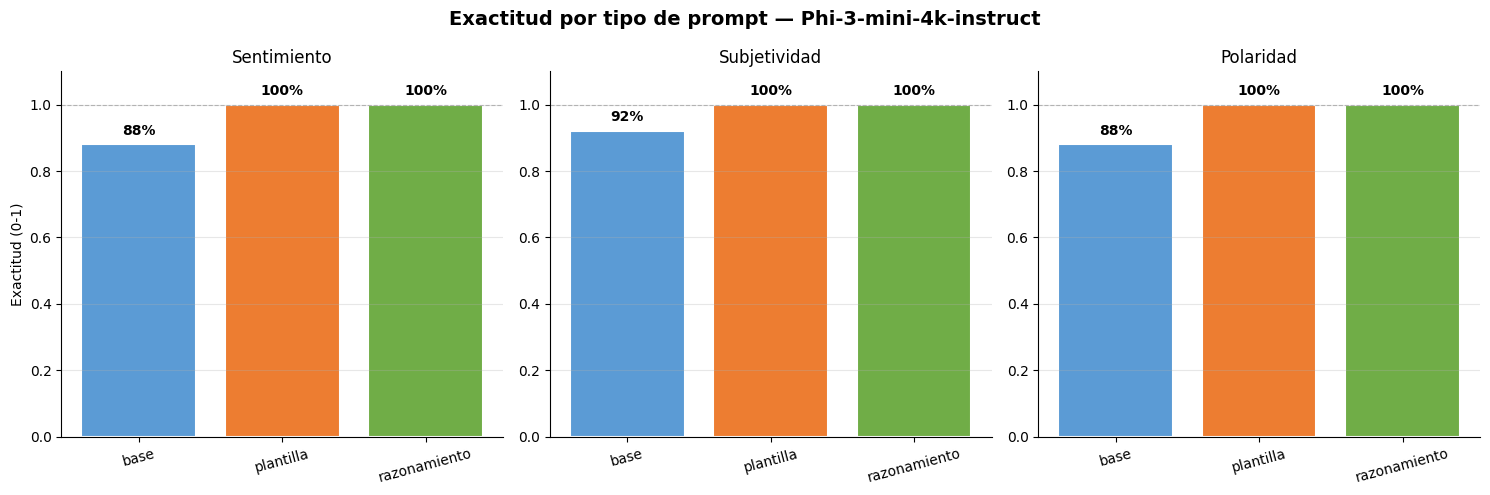

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Exactitud por tipo de prompt — Phi-3-mini-4k-instruct", fontsize=14, fontweight="bold")

categorias = [
    ("exactitud_sentimiento", "Sentimiento"),
    ("exactitud_subjetividad", "Subjetividad"),
    ("exactitud_polaridad", "Polaridad"),
]

colores = {"base": "#5B9BD5", "plantilla": "#ED7D31", "razonamiento": "#70AD47"}

for ax, (col, titulo) in zip(axes, categorias):
    valores = resumen_objetivo[col].reindex(["base", "plantilla", "razonamiento"])
    bars = ax.bar(
        valores.index,
        valores.values,
        color=[colores[k] for k in valores.index],
        edgecolor="white",
        linewidth=1.5
    )
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel("Exactitud (0-1)" if ax == axes[0] else "")
    ax.set_ylim(0, 1.1)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticklabels(valores.index, rotation=15)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("exactitud_por_prompt.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1453/3182334331.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(datos_box, labels=etiquetas_box, patch_artist=True,


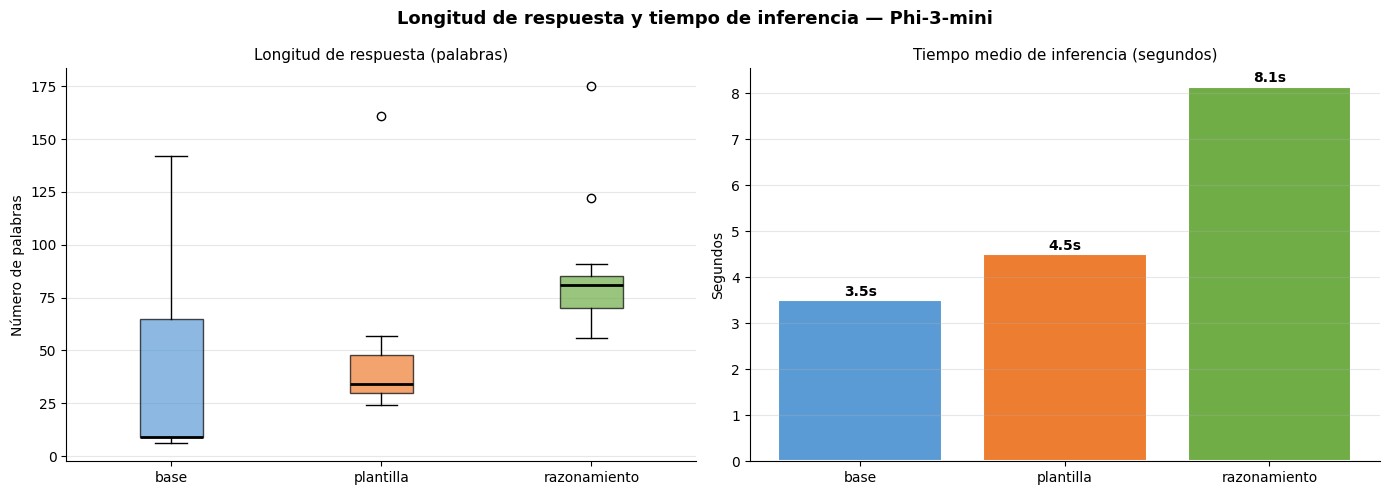

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Longitud de respuesta y tiempo de inferencia — Phi-3-mini", fontsize=13, fontweight="bold")

# Boxplot longitud
datos_box = []
etiquetas_box = []
for tipo in ["base", "plantilla", "razonamiento"]:
    datos_box.append(df_resultados[df_resultados["tipo_prompt"] == tipo]["longitud_palabras"].values)
    etiquetas_box.append(tipo)

bp = axes[0].boxplot(datos_box, labels=etiquetas_box, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], ["#5B9BD5", "#ED7D31", "#70AD47"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Longitud de respuesta (palabras)", fontsize=11)
axes[0].set_ylabel("Número de palabras")
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Barras tiempo medio de inferencia
tiempos = resumen_objetivo["tiempo_medio_s"].reindex(["base", "plantilla", "razonamiento"])
axes[1].bar(tiempos.index, tiempos.values,
            color=["#5B9BD5", "#ED7D31", "#70AD47"], edgecolor="white", linewidth=1.5)
axes[1].set_title("Tiempo medio de inferencia (segundos)", fontsize=11)
axes[1].set_ylabel("Segundos")
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
for i, (label, val) in enumerate(zip(tiempos.index, tiempos.values)):
    axes[1].text(i, val + 0.1, f"{val:.1f}s", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("longitud_tiempo_por_prompt.png", dpi=150, bbox_inches="tight")
plt.show()

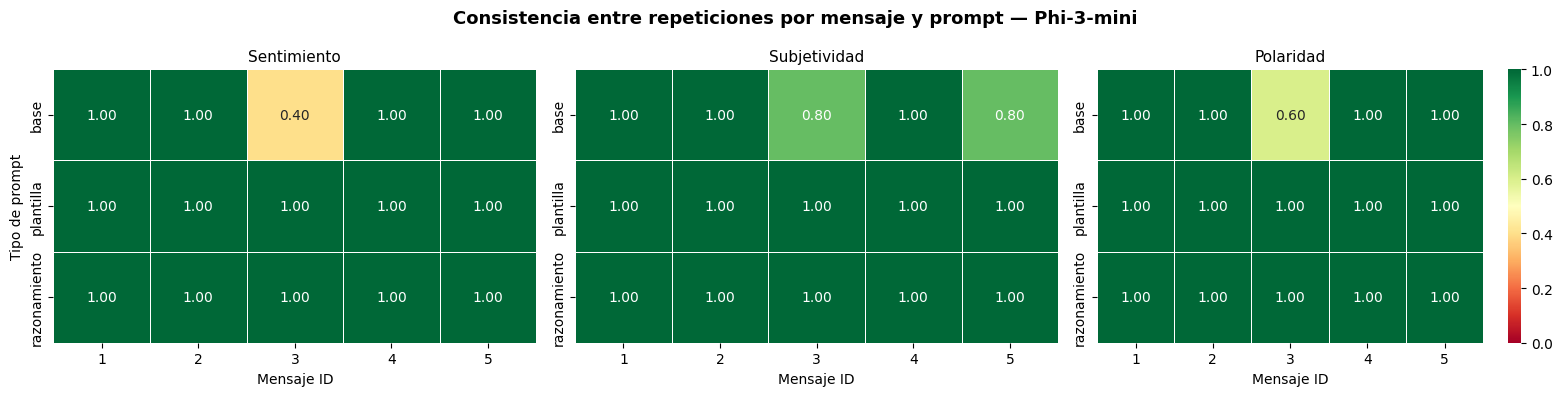

In [25]:
# Heatmap de consistencia por prompt y mensaje
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Consistencia entre repeticiones por mensaje y prompt — Phi-3-mini", fontsize=13, fontweight="bold")

for ax, (col, titulo) in zip(axes, [
    ("consist_sentimiento", "Sentimiento"),
    ("consist_subjetividad", "Subjetividad"),
    ("consist_polaridad", "Polaridad"),
]):
    pivot = consistencia[col].unstack(level="mensaje_id")
    pivot = pivot.reindex(["base", "plantilla", "razonamiento"])
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, linewidths=0.5, cbar=ax == axes[-1]
    )
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Mensaje ID")
    ax.set_ylabel("Tipo de prompt" if ax == axes[0] else "")

plt.tight_layout()
plt.savefig("consistencia_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Conclusiones <a id='sec11'></a>

### 10.1 Resultados principales

> *(Completar tras revisar los resultados del experimento)*

**Exactitud global:**
- Prompt base: ...
- Prompt plantilla: ...
- Prompt razonamiento: ...

**Consistencia:**
- El modelo muestra mayor/menor estabilidad con el prompt ...
- Los mensajes más inconsistentes fueron ...

### 10.2 Comparación entre estrategias de prompting

> *(Completar)*

- El **prompt base** produce respuestas ... porque ...
- El **prompt plantilla** mejora/empeora ... porque ...
- El **prompt de razonamiento** destaca en ... aunque introduce ...

### 10.3 Comportamiento del modelo Phi-3-mini

> *(Completar)*

- Fortalezas observadas: ...
- Debilidades observadas: ...
- Casos en los que el modelo falla sistemáticamente: ...

### 10.4 Limitaciones del experimento

- Dataset reducido (5 mensajes): los resultados no son estadísticamente representativos.
- La evaluación subjetiva depende del criterio del evaluador.
- Los resultados pueden variar entre ejecuciones por la naturaleza estocástica del modelo (temperature=0.7).
- El modelo puede tener sesgos derivados de su entrenamiento que afectan a categorías específicas.

### 10.5 Reflexión final

> *(Completar con las conclusiones del grupo)*